In [12]:
import os
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

os.makedirs("data", exist_ok=True)

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42
)

# Randomly set 85% of feature values to 0
np.random.seed(42)
mask = np.random.rand(1000, 20) < 0.85
X[mask] = 0.0

# Combine features (X) and target (y) into a DataFrame
dataset = pd.DataFrame(X, columns=[f"feature_{i+1}" for i in range(20)])
dataset["target"] = y

file_path = "data/sparse_toy_dataset.csv"
dataset.to_csv(file_path, index=False)

print(f"Dataset saved to {file_path}")
print(f"Dataset size: {dataset.shape}")
print(f"Percentage of zeros in features: {(dataset.drop('target', axis=1) == 0).mean().mean() * 100:.2f}%")

Dataset saved to data/sparse_toy_dataset.csv
Dataset size: (1000, 21)
Percentage of zeros in features: 84.93%


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv("data/sparse_toy_dataset.csv")

# Separate features (X) and target labels (y)
X = dataset.drop("target", axis=1).values
y = dataset["target"].values

X = np.c_[np.ones(X.shape[0]), X]

print(f"Loaded dataset with {X.shape[0]} samples and {X.shape[1]} features (including bias).")

Loaded dataset with 1000 samples and 21 features (including bias).


In [14]:
# it convert scores to probabilities
def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))


def compute_gradient(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    gradient = np.dot(X_batch.T, (predictions - y_batch)) / len(y_batch)
    return gradient

def compute_loss(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    loss = -np.mean(y_batch * np.log(predictions) + (1 - y_batch) * np.log(1 - predictions))
    return loss

In [15]:
def train_adagrad(X, y, epochs=50, eta=0.1, delta=1e-8):
    weights = np.zeros(X.shape[1])

    # track of past squared gradients, starting at zero
    sum_sq_gradients = np.zeros(X.shape[1])

    loss_history = []

    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)

        sum_sq_gradients += gradient ** 2

        H_t = np.sqrt(sum_sq_gradients) + delta

        weights -= (eta / H_t) * gradient

        current_loss = compute_loss(X, y, weights)
        loss_history.append(current_loss)

    return weights, loss_history

Training Finished! Final Accuracy: 63.00%


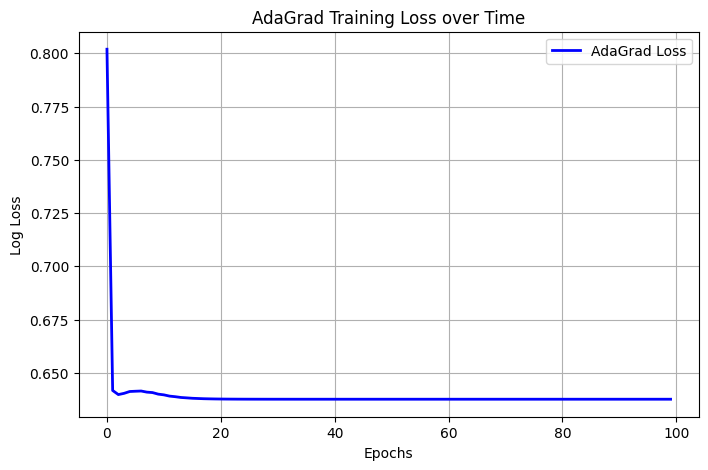

In [16]:

final_weights, adagrad_loss = train_adagrad(X, y, epochs=100, eta=0.5)

final_predictions = sigmoid(np.dot(X, final_weights)) >= 0.5
accuracy = np.mean(final_predictions == y) * 100

print(f"Training Finished! Final Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(adagrad_loss, label="AdaGrad Loss", color="blue", linewidth=2)
plt.title("AdaGrad Training Loss over Time")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)

import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/adagrad_training_loss.png")
plt.show()